In [1]:
# installs (if needed again)
%pip install xarray netCDF4 huggingface_hub matplotlib

# imports
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import ast
import tarfile
from huggingface_hub import HfApi, hf_hub_download, hf_hub_url, login
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import gc
from collections import Counter

login()  # paste your HF token again

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 41.8 MB/s eta 0:00:00


In [2]:
def get_pre_post(ds):
    raw = ds.attrs.get('pre_post_dates', None)
    if not raw:
        return None, None
    try:
        d = ast.literal_eval(raw)
        return d.get('pre'), d.get('post')
    except Exception:
        return None, None

def normalize_adaptive(img):
    p2, p98 = np.percentile(img, (2, 98))
    return np.clip((img - p2) / (p98 - p2 + 1e-6), 0, 1)

In [3]:
extract_path_s1 = "/content/data/data_harmonized/s1asc"

s1_path = hf_hub_download(
    repo_id="paulhoehn/Sen12Landslides",
    filename="data_harmonized/s1asc/s1asc_part01.tar.gz",
    repo_type="dataset",
    local_dir="/content/data"
)

with tarfile.open(s1_path, "r:gz") as tar:
    tar.extractall(path=extract_path_s1)

s1_files = [f for f in os.listdir(extract_path_s1) if f.endswith(".nc")]
print("Total S1 files:", len(s1_files))

data_harmonized/s1asc/s1asc_part01.tar.g(…): reconstructing file:   0%|          |  0.00B / 1.49GB            

data_harmonized/s1asc/s1asc_part01.tar.g(…): downloading bytes:           |  0.00B            

/tmp/ipykernel_407/3139295822.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path_s1)


Total S1 files: 1000


In [4]:
found_event = False
for fname in s1_files:
    ds_check = xr.open_dataset(os.path.join(extract_path_s1, fname))
    p_idx, po_idx = get_pre_post(ds_check)
    if p_idx is not None:
        ds_s1 = ds_check
        pre_idx_s1, post_idx_s1 = p_idx, po_idx
        print(f"Found event sample: {fname}")
        found_event = True
        break
    ds_check.close()

Found event sample: chimanimani_s1asc_1494.nc


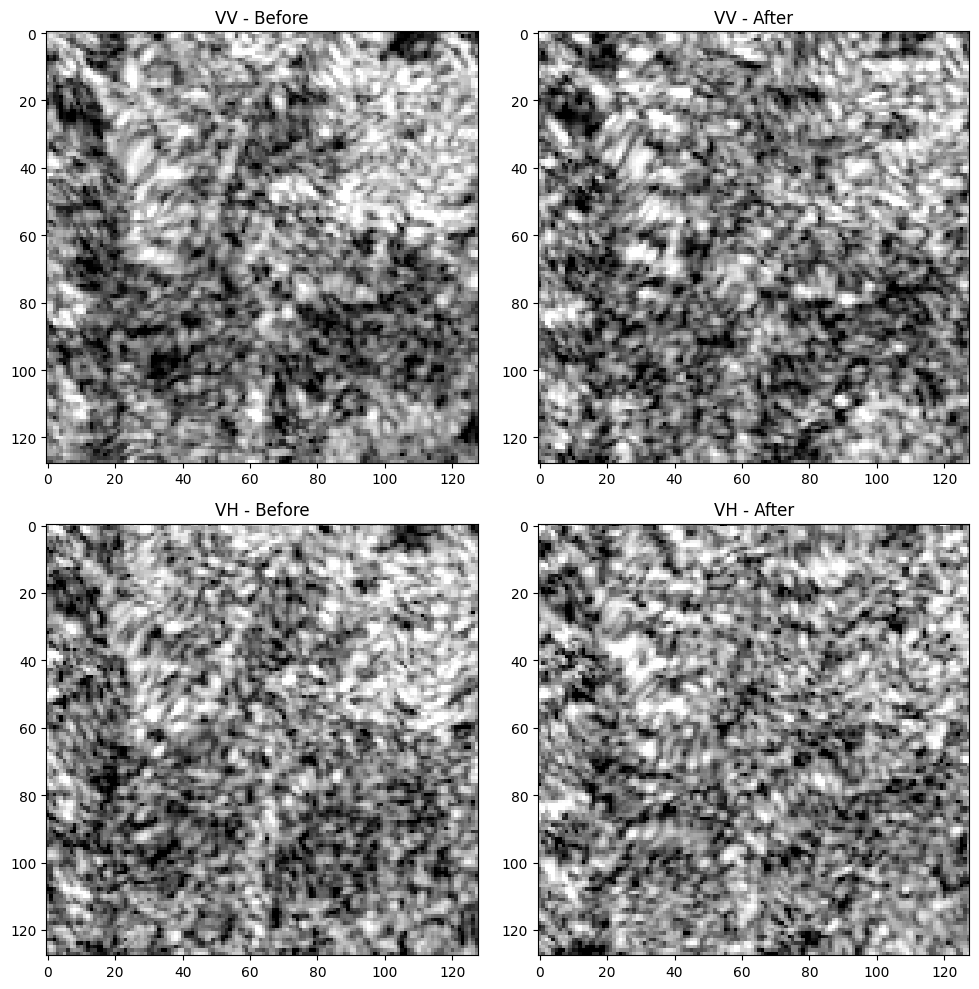

In [5]:
def get_radar_image(ds, t_idx):
    vv = ds['VV'].isel(time=t_idx).values
    vh = ds['VH'].isel(time=t_idx).values
    vv_norm = normalize_adaptive(vv)
    vh_norm = normalize_adaptive(vh)
    return vv_norm, vh_norm

vv_pre, vh_pre = get_radar_image(ds_s1, pre_idx_s1)
vv_post, vh_post = get_radar_image(ds_s1, post_idx_s1)

fig, axes = plt.subplots(2, 2, figsize=(10,10))
axes[0,0].imshow(vv_pre, cmap='gray'); axes[0,0].set_title("VV - Before")
axes[0,1].imshow(vv_post, cmap='gray'); axes[0,1].set_title("VV - After")
axes[1,0].imshow(vh_pre, cmap='gray'); axes[1,0].set_title("VH - Before")
axes[1,1].imshow(vh_post, cmap='gray'); axes[1,1].set_title("VH - After")
plt.tight_layout()
plt.show()

In [6]:
def build_dataset_s1(file_list, folder):
    X, y = [], []
    for fname in file_list:
        try:
            ds = xr.open_dataset(os.path.join(folder, fname))
            pre_idx, post_idx = get_pre_post(ds)
            t_idx = post_idx if post_idx is not None else ds.sizes['time'] - 1

            vv = ds['VV'].isel(time=t_idx).values
            vh = ds['VH'].isel(time=t_idx).values
            vv_n = normalize_adaptive(vv)
            vh_n = normalize_adaptive(vh)

            img = np.stack([vv_n, vh_n, vv_n], axis=-1).astype(np.float32)  # 3rd channel duplicated to reuse your existing U-Net (expects 3 channels)

            mask = ds['MASK'].isel(time=t_idx).values.astype(np.float32)

            X.append(img)
            y.append(mask)
            ds.close()
        except Exception:
            continue
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)[..., np.newaxis]

X_s1, y_s1 = build_dataset_s1(s1_files, extract_path_s1)
print("S1 dataset shape:", X_s1.shape)
gc.collect()

S1 dataset shape: (1000, 128, 128, 3)


301

In [7]:
print("GPUs detected:", tf.config.list_physical_devices('GPU'))


GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
import tensorflow.keras.backend as K
import tensorflow as tf
from tensorflow.keras import layers, models

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

def build_unet(input_shape=(128,128,3)):
    inputs = layers.Input(input_shape)

    # Encoder (downsampling path)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(c3)

    # Decoder
    u2 = layers.UpSampling2D()(c3)
    u2 = layers.Concatenate()([u2, c2])  # skip connection
    c4 = layers.Conv2D(32, 3, activation='relu', padding='same')(u2)
    c4 = layers.Conv2D(32, 3, activation='relu', padding='same')(c4)

    u1 = layers.UpSampling2D()(c4)
    u1 = layers.Concatenate()([u1, c1])  # skip connection
    c5 = layers.Conv2D(16, 3, activation='relu', padding='same')(u1)
    c5 = layers.Conv2D(16, 3, activation='relu', padding='same')(c5)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c5)

    return models.Model(inputs, outputs)

X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(
    X_s1, y_s1, test_size=0.2, random_state=42
)

gc.collect()
unet_s1 = build_unet()
unet_s1.compile(optimizer='adam', loss=combined_loss, metrics=[dice_coef])

early_stop_s1 = EarlyStopping(monitor='val_dice_coef', mode='max', patience=5, restore_best_weights=True)

history_s1 = unet_s1.fit(
    X_train_s1, y_train_s1,
    validation_data=(X_test_s1, y_test_s1),
    epochs=50,
    batch_size=8,
    callbacks=[early_stop_s1]
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - dice_coef: 0.0106 - loss: 1.0746 - val_dice_coef: 0.0148 - val_loss: 1.0547
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - dice_coef: 0.0134 - loss: 1.0460 - val_dice_coef: 0.0159 - val_loss: 1.0546
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - dice_coef: 0.0167 - loss: 1.0422 - val_dice_coef: 0.0247 - val_loss: 1.0462
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - dice_coef: 0.0237 - loss: 1.0364 - val_dice_coef: 0.0317 - val_loss: 1.0422
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - dice_coef: 0.0296 - loss: 1.0321 - val_dice_coef: 0.0379 - val_loss: 1.0380
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - dice_coef: 0.0372 - loss: 1.0254 - val_dice_coef: 0.0381 - val_loss: 1.0350
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - dice_coef: 0.0380 - loss: 1.0245 - val_dice_coef: 0.0366 - val_loss: 1.0352
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - dice_coef: 0.0449 - loss: 1

In [9]:
regions_s1_check = Counter(f.split('_')[0] for f in s1_files)
print("Regions in this S1 batch:", regions_s1_check)

Regions in this S1 batch: Counter({'chimanimani': 1000})


In [10]:
extract_path = "/content/data/data_harmonized/s2"
nc_dir = extract_path

import tarfile
from huggingface_hub import hf_hub_download

# Ensure the s2 directory exists and contains data
s2_part01_path = hf_hub_download(
    repo_id="paulhoehn/Sen12Landslides",
    filename="data_harmonized/s2/s2_part01.tar.gz",
    repo_type="dataset",
    local_dir="/content/data"
)

# Create the target directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

with tarfile.open(s2_part01_path, "r:gz") as tar:
    tar.extractall(path=extract_path)

print("S2 part01 extraction complete.")

def build_dataset_fused(s1_folder, s2_folder, region_prefix='chimanimani', limit=500):
    X, y = [], []
    s1_names = {f.split('_s1asc_')[1]: f for f in os.listdir(s1_folder) if f.startswith(region_prefix)}
    s2_names = {f.split('_s2_')[1]: f for f in os.listdir(s2_folder) if f.startswith(region_prefix)}

    common_ids = set(s1_names.keys()) & set(s2_names.keys())
    print(f"Matching {region_prefix} samples across both sensors:", len(common_ids))

    for uid in list(common_ids)[:limit]:
        try:
            ds1 = xr.open_dataset(os.path.join(s1_folder, s1_names[uid]))
            ds2 = xr.open_dataset(os.path.join(s2_folder, s2_names[uid]))

            pre_idx, post_idx = get_pre_post(ds2)
            t_idx = post_idx if post_idx is not None else ds2.sizes['time'] - 1

            vv = normalize_adaptive(ds1['VV'].isel(time=t_idx).values)
            vh = normalize_adaptive(ds1['VH'].isel(time=t_idx).values)
            r = ds2['B04'].isel(time=t_idx).values
            g = ds2['B03'].isel(time=t_idx).values
            b = ds2['B02'].isel(time=t_idx).values
            optical = np.clip(np.stack([r,g,b], axis=-1).astype(np.float32) / 3000, 0, 1)

            fused = np.concatenate([optical, vv[...,None], vh[...,None]], axis=-1)  # 5 channels: R,G,B,VV,VH

            mask = ds2['MASK'].isel(time=t_idx).values.astype(np.float32)

            X.append(fused)
            y.append(mask)
            ds1.close(); ds2.close()
        except Exception:
            continue
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)[..., np.newaxis]

X_fused, y_fused = build_dataset_fused(extract_path_s1, nc_dir)
print("Fused dataset shape:", X_fused.shape)

data_harmonized/s2/s2_part01.tar.gz: reconstructing file:   0%|          |  0.00B / 1.47GB            

data_harmonized/s2/s2_part01.tar.gz: downloading bytes:           |  0.00B            

/tmp/ipykernel_407/4028261101.py:19: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


S2 part01 extraction complete.
Matching chimanimani samples across both sensors: 500
Fused dataset shape: (500, 128, 128, 5)
